# Trabalho Prático: Persistência de Dados e Análise SQL

Este notebook realiza a modelagem, criação e população de um banco de dados relacional para uma fintech (`fintech_integrada.db`), integrando dados da API pública do IBGE e executando análises com Pandas e Matplotlib.

---

## 📌 Requisitos de Integridade e Conceitos Aplicados

1. **Chaves Primárias (PKs):**
   - `id` em todas as tabelas garante a unicidade e identificação exclusiva de cada registro.
   - A coluna `matricula` na tabela `estudantes` utiliza a restrição `UNIQUE` para evitar matrículas duplicadas.

2. **Chaves Estrangeiras (FKs):**
   - Na tabela `despesas`, `estudante_id` referencia `estudantes(id)` e `municipio_id` referencia `municipios(id)`.
   - Garantem que nenhuma despesa exista sem estar associada a um estudante válido e a um município existente.
   - O comando `PRAGMA foreign_keys = ON;` é executado explicitamente para ativar a validação do SQLite.

3. **Importância das Transações (ACID):**
   - Através do bloco `try/except` com controle manual de `BEGIN TRANSACTION`, `COMMIT` e `ROLLBACK`, assegura-se a **atomicidade**.
   - A função `registrar_venda_segura` grava a criação de um estudante e sua despesa associada como uma única unidade de trabalho. Se a inserção da despesa falhar, o `ROLLBACK` desfaz a criação do estudante, evitando dados órfãos ou inconsistentes.

## Configuração do Ambiente e Criação do Banco (DDL)

In [ ]:
import os
import sqlite3
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Definindo o banco local para garantir reprodutibilidade em qualquer ambiente
db_path = 'fintech_integrada.db'

# Conexão e Ativação de Foreign Keys
conn = sqlite3.connect(db_path)
cursor = conn.cursor()
cursor.execute("PRAGMA foreign_keys = ON;")

# Criação do Esquema do Banco de Dados (DDL)
cursor.executescript("""
CREATE TABLE IF NOT EXISTS estudantes (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    nome TEXT NOT NULL,
    matricula TEXT UNIQUE NOT NULL
);

CREATE TABLE IF NOT EXISTS municipios (
    id INTEGER PRIMARY KEY,
    nome TEXT NOT NULL,
    uf_sigla TEXT NOT NULL
);

CREATE TABLE IF NOT EXISTS despesas (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    valor REAL NOT NULL,
    data TEXT NOT NULL,
    estudante_id INTEGER NOT NULL,
    municipio_id INTEGER NOT NULL,
    FOREIGN KEY (estudante_id) REFERENCES estudantes(id) ON DELETE CASCADE,
    FOREIGN KEY (municipio_id) REFERENCES municipios(id) ON DELETE CASCADE
);
""")

conn.commit()
conn.close()
print(f"Banco de dados inicializado com sucesso em: {db_path}")

Banco de dados inicializado com sucesso em: fintech_integrada.db


## Integração da API do IBGE (População da Tabela Municipios)

In [ ]:
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Captura de dados da API do IBGE
url_ibge = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"
response = requests.get(url_ibge)
municipios_json = response.json()

# Tratamento seguro de campos nulos e navegação no JSON
dados_municipios = []
for m in municipios_json:
    microrregiao = m.get('microrregiao')
    if microrregiao and isinstance(microrregiao, dict):
        uf_sigla = microrregiao.get('mesorregiao', {}).get('UF', {}).get('sigla', 'N/A')
    else:
        regiao_imediata = m.get('regiao-imediata')
        if regiao_imediata and isinstance(regiao_imediata, dict):
            uf_sigla = regiao_imediata.get('regiao-intermediaria', {}).get('UF', {}).get('sigla', 'N/A')
        else:
            uf_sigla = 'N/A'

    dados_municipios.append((m['id'], m['nome'], uf_sigla))

# Inserção em lote no banco
cursor.executemany("""
    INSERT OR IGNORE INTO municipios (id, nome, uf_sigla)
    VALUES (?, ?, ?)
""", dados_municipios)

conn.commit()

cursor.execute("SELECT COUNT(*) FROM municipios")
total_mun = cursor.fetchone()[0]
print(f"Total de municípios carregados do IBGE: {total_mun}")

conn.close()

Total de municípios carregados do IBGE: 5571


## Transação Segura com Controle de Erros (Try / Except / Rollback)

In [ ]:
def registrar_venda_segura(nome, matricula, valor, data, municipio_id):
    """
    Insere estudante e despesa associada de forma atômica.
    Aplica ROLLBACK automático em caso de falha.
    """
    conn = sqlite3.connect(db_path, isolation_level=None)
    cursor = conn.cursor()
    cursor.execute("PRAGMA foreign_keys = ON;")

    try:
        cursor.execute("BEGIN TRANSACTION;")

        # Inserção do Estudante
        cursor.execute("""
            INSERT INTO estudantes (nome, matricula) VALUES (?, ?)
        """, (nome, matricula))

        estudante_id = cursor.lastrowid

        # Inserção da Despesa associada
        cursor.execute("""
            INSERT INTO despesas (valor, data, estudante_id, municipio_id)
            VALUES (?, ?, ?, ?)
        """, (valor, data, estudante_id, municipio_id))

        cursor.execute("COMMIT;")
        print(f"✅ Sucesso: Registro de '{nome}' efetuado.")

    except Exception as e:
        cursor.execute("ROLLBACK;")
        print(f"❌ Erro na transação ({e}). ROLLBACK executado.")

    finally:
        conn.close()

# Inserção de dados de teste
print("--- Executando inserções seguras ---")
registrar_venda_segura("Ana Silva", "202601", 250.00, "2026-09-01", 3550308) # São Paulo
registrar_venda_segura("Carlos Souza", "202602", 180.50, "2026-09-02", 3304557) # Rio de Janeiro
registrar_venda_segura("Mariana Lima", "202603", 310.00, "2026-09-03", 3106200) # Belo Horizonte
registrar_venda_segura("Pedro Alves", "202604", 120.00, "2026-09-04", 3550308) # São Paulo

--- Executando inserções seguras ---
✅ Sucesso: Registro de 'Ana Silva' efetuado.
✅ Sucesso: Registro de 'Carlos Souza' efetuado.
✅ Sucesso: Registro de 'Mariana Lima' efetuado.
✅ Sucesso: Registro de 'Pedro Alves' efetuado.


## Consultas SQL, Análise Pandas e Gráfico

--- 1. Listagem de Despesas com JOIN ---


,despesa_id,estudante,valor,data,municipio,estado
0,1,Ana Silva,250.0,2026-09-01,São Paulo,SP
1,2,Carlos Souza,180.5,2026-09-02,Rio de Janeiro,RJ
2,3,Mariana Lima,310.0,2026-09-03,Belo Horizonte,MG
3,4,Pedro Alves,120.0,2026-09-04,São Paulo,SP



--- 2. Somatório de Despesas por Estado ---


,estado,total_despesas
0,SP,370.0
1,MG,310.0
2,RJ,180.5


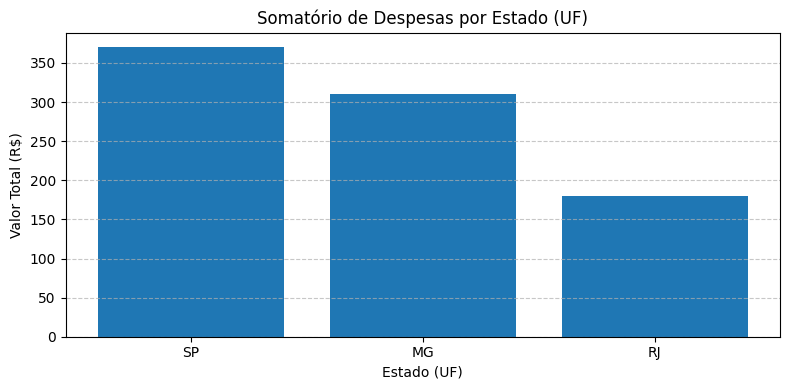

In [ ]:
conn = sqlite3.connect(db_path)

# 1. Visão 1: Listagem completa de despesas com JOIN
query_1 = """
SELECT
    d.id AS despesa_id,
    e.nome AS estudante,
    d.valor,
    d.data,
    m.nome AS municipio,
    m.uf_sigla AS estado
FROM despesas d
JOIN estudantes e ON d.estudante_id = e.id
JOIN municipios m ON d.municipio_id = m.id;
"""

df_detalhado = pd.read_sql_query(query_1, conn)
print("--- 1. Listagem de Despesas com JOIN ---")
display(df_detalhado)

# 2. Visão 2: Agrupamento e Somatório por Estado
query_2 = """
SELECT
    m.uf_sigla AS estado,
    SUM(d.valor) AS total_despesas
FROM despesas d
JOIN municipios m ON d.municipio_id = m.id
GROUP BY m.uf_sigla
ORDER BY total_despesas DESC;
"""

df_por_estado = pd.read_sql_query(query_2, conn)
print("\n--- 2. Somatório de Despesas por Estado ---")
display(df_por_estado)

# 3. Gráfico de Barras
plt.figure(figsize=(8, 4))
plt.bar(df_por_estado['estado'], df_por_estado['total_despesas'], color='#1f77b4')
plt.title('Somatório de Despesas por Estado (UF)')
plt.xlabel('Estado (UF)')
plt.ylabel('Valor Total (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

conn.close()